# Análisis de Marketing y Rentabilidad de Clientes en Showz
La adquisición de clientes representa una de las inversiones más importantes para cualquier empresa digital. Sin embargo, atraer usuarios no siempre garantiza rentabilidad, por lo que resulta fundamental comprender cómo interactúan los clientes con la plataforma, cuánto valor generan a lo largo del tiempo y si los ingresos obtenidos compensan los costos de captación.

En este proyecto se analizarán los datos de la empresa Showz, dedicada a la venta de entradas para eventos. El **objetivo principal** es evaluar el desempeño de las estrategias de marketing mediante el estudio del comportamiento de los usuarios, los patrones de compra y la rentabilidad de los distintos canales de adquisición.

A través del análisis de visitas, pedidos e inversiones publicitarias, se buscará responder preguntas clave relacionadas con el ciclo de vida del cliente y la eficiencia de las campañas de marketing.

Los principales objetivos de la investigación son:
* Comprender cómo los usuarios utilizan la plataforma.
* Identificar cuánto tiempo transcurre hasta la primera compra.
* Determinar el valor económico que aporta cada cliente.
* Analizar cuándo los ingresos generados compensan los costos de adquisición.
* Evaluar la rentabilidad de las distintas fuentes de marketing.
* Generar recomendaciones basadas en datos para optimizar la asignación del presupuesto publicitario.

Por lo tanto, Showz necesita optimizar sus inversiones en marketing y comprender qué canales generan clientes más rentables a largo plazo.

Para ello, se analizarán indicadores clave como:
* DAU, WAU y MAU.
* Tasa de conversión.
* Tiempo hasta la primera compra.
* LTV (Lifetime Value).
* CAC (Customer Acquisition Cost).
* ROMI (Return on Marketing Investment).

El análisis permitirá identificar qué estrategias generan el mayor retorno económico y cuáles requieren ajustes para mejorar la eficiencia del gasto publicitario.

## Acceso a datos y prepararlos para el análisis

In [1]:
# Cargar la librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar las rutas de archivos
visits = pd.read_csv(r"C:\Users\ricar\OneDrive\Escritorio\TRIPLETEN\Proyectos CV\Proyecto de Marketing Analytics del Departamento de Showz\CSV Proyecto de Marketing Analytics del Departamento de Showz\visits_log_us.csv")
orders = pd.read_csv(r"C:\Users\ricar\OneDrive\Escritorio\TRIPLETEN\Proyectos CV\Proyecto de Marketing Analytics del Departamento de Showz\CSV Proyecto de Marketing Analytics del Departamento de Showz\orders_log_us.csv")
costs = pd.read_csv(r"C:\Users\ricar\OneDrive\Escritorio\TRIPLETEN\Proyectos CV\Proyecto de Marketing Analytics del Departamento de Showz\CSV Proyecto de Marketing Analytics del Departamento de Showz\costs_us.csv")

In [3]:
# Visualización de la información del DataFrame vists
visits.info()
print('-----------------------------------------------------------------------')
print(visits.head(10))

<class 'pandas.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  str   
 1   End Ts     359400 non-null  str   
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  str   
 4   Uid        359400 non-null  uint64
dtypes: int64(1), str(3), uint64(1)
memory usage: 13.7 MB
-----------------------------------------------------------------------
    Device               End Ts  Source Id             Start Ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   
3  desktop  2018-05-20 11:23:00          9  2018-05-20 10:59:00   
4  desktop  2017-12-27 14:06:00          3  2017-12-27 14:06:00   
5  desktop  2017-09-03 21:36:00          5  2017-09-03 21:35:00   
6  desktop  2018-01-30

In [4]:
# Visualización de la información del DataFrame orders
orders.info()
print('-----------------------------------------------------------------------')
print(orders.head(10))

<class 'pandas.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  str    
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), str(1), uint64(1)
memory usage: 1.2 MB
-----------------------------------------------------------------------
                Buy Ts  Revenue                   Uid
0  2017-06-01 00:10:00    17.00  10329302124590727494
1  2017-06-01 00:25:00     0.55  11627257723692907447
2  2017-06-01 00:27:00     0.37  17903680561304213844
3  2017-06-01 00:29:00     0.55  16109239769442553005
4  2017-06-01 07:58:00     0.37  14200605875248379450
5  2017-06-01 08:43:00     0.18  10402394430196413321
6  2017-06-01 08:54:00     1.83  12464626743129688638
7  2017-06-01 09:22:00     1.22   3644482766749211722
8  2017-06-01 09:22:00     3.30  17542070709969841479
9  2017-06-01 09:23:00     0.37   10743551

In [5]:
# Visualización de la información del DataFrame costs
costs.info()
print('-----------------------------------------------------------------------')
print(costs.head(10))

<class 'pandas.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   str    
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), str(1)
memory usage: 59.7 KB
-----------------------------------------------------------------------
   source_id          dt  costs
0          1  2017-06-01  75.20
1          1  2017-06-02  62.25
2          1  2017-06-03  36.53
3          1  2017-06-04  55.00
4          1  2017-06-05  57.08
5          1  2017-06-06  40.39
6          1  2017-06-07  40.59
7          1  2017-06-08  56.63
8          1  2017-06-09  40.16
9          1  2017-06-10  43.24


In [6]:
# Convertir los nombres de las columnas a minúsculas para facilitar el análisis
visits.columns = visits.columns.str.lower()
orders.columns = orders.columns.str.lower()
costs.columns = costs.columns.str.lower()

# Reemplazar los espacios en los nombres de las columnas por guiones bajos para facilitar el acceso a las columnas
visits.columns = visits.columns.str.replace(' ', '_')
orders.columns = orders.columns.str.replace(' ', '_')  
costs.columns = costs.columns.str.replace(' ', '_')

# Mostrar las primeras filas de cada DataFrame para verificar los cambios
print("DataFrame visits:")
print(visits.head())
print('-----------------------------------------------------------------------')
print("DataFrame orders:")
print(orders.head())
print('-----------------------------------------------------------------------')
print("DataFrame costs:")
print(costs.head())

DataFrame visits:
    device               end_ts  source_id             start_ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   
3  desktop  2018-05-20 11:23:00          9  2018-05-20 10:59:00   
4  desktop  2017-12-27 14:06:00          3  2017-12-27 14:06:00   

                    uid  
0  16879256277535980062  
1    104060357244891740  
2   7459035603376831527  
3  16174680259334210214  
4   9969694820036681168  
-----------------------------------------------------------------------
DataFrame orders:
                buy_ts  revenue                   uid
0  2017-06-01 00:10:00    17.00  10329302124590727494
1  2017-06-01 00:25:00     0.55  11627257723692907447
2  2017-06-01 00:27:00     0.37  17903680561304213844
3  2017-06-01 00:29:00     0.55  16109239769442553005
4  2017-06-01 07:58:00     0.37  14200605875248379450
---------

In [7]:
# DataFrame visits: convertir la columna date a formato datetime
visits['end_ts'] = pd.to_datetime(visits['end_ts'])
visits['start_ts'] = pd.to_datetime(visits['start_ts'])
# DataFrame orders: convertir la columna date a formato datetime
orders['buy_ts'] = pd.to_datetime(orders['buy_ts'])
# DataFrame costs: convertir la columna date a formato datetime
costs['dt'] = pd.to_datetime(costs['dt'])

## Análisis de Actividad y Comportamiento de Usuarios
Antes de evaluar la rentabilidad de las campañas de marketing, es fundamental comprender cómo los usuarios interactúan con la plataforma. Analizar los patrones de actividad permite identificar el nivel de engagement de los clientes, la frecuencia con la que utilizan el servicio y la evolución de su participación a lo largo del tiempo.

En esta sección se estudiarán las métricas de uso más relevantes de Showz, incluyendo la cantidad de usuarios activos diarios (DAU), semanales (WAU) y mensuales (MAU). Estas métricas permitirán dimensionar el alcance de la plataforma y comprender el comportamiento general de la audiencia.

Además, se crearán variables temporales que facilitarán la agregación de la información por día, semana y mes, permitiendo analizar tendencias de actividad y detectar posibles patrones de uso.

### Preparación de Variables Temporales

Para analizar la actividad de los usuarios en distintos niveles de tiempo, se generan variables auxiliares que permiten agrupar la información por día, semana y mes. Estas transformaciones facilitarán el cálculo de métricas de actividad y la construcción de los indicadores de uso de la plataforma.

In [8]:
# ¿Cuántas personas lo usan cada día, semana y mes?

# Creación de columnas con los datos para identificar la Actividad del Usuario en el DataFrame visits
visits['user_year'] = visits['start_ts'].dt.isocalendar().year
visits['user_month'] = visits['start_ts'].dt.month
visits['user_week'] = visits['start_ts'].dt.isocalendar().week
visits['user_date'] = visits['start_ts'].dt.date

### Usuarios Activos Diarios, Semanales y Mensuales (DAU, WAU y MAU)
Objetivo: cuantificar el tamaño de la audiencia activa de Showz y evaluar la frecuencia con la que los usuarios utilizan la plataforma.

In [9]:
# Creación de DAU, WAU y MAU
visits_dau = (visits.groupby('user_date')
              .agg({'uid':'nunique'})['uid']
              .mean())
visits_wau = (visits.groupby(['user_year', 'user_week'])
              .agg({'uid':'nunique'})['uid']
              .mean())
visits_mau = (visits.groupby(['user_year', 'user_month'])
              .agg({'uid':'nunique'})['uid']
              .mean())

# Imprimir los resultados
print(f'La cantidad de personas que lo utilizan diariamente son {int(visits_dau)}, semanalmente son {int(visits_wau)} y mensualmente son {int(visits_mau)} personas.')

La cantidad de personas que lo utilizan diariamente son 907, semanalmente son 5716 y mensualmente son 23228 personas.


### Frecuencia de Uso: Número de Sesiones por Usuario
Una vez identificada la cantidad de usuarios activos, resulta relevante analizar con qué frecuencia interactúan con la plataforma. El número de sesiones permite medir el nivel de participación de los usuarios y comprender si el servicio es utilizado de manera ocasional o recurrente.

En esta sección se calculará la cantidad de sesiones registradas por día y el promedio de sesiones generadas por usuario. Estos indicadores ayudarán a evaluar el grado de engagement de la audiencia y proporcionarán una visión más detallada sobre los hábitos de uso dentro de la plataforma Showz.

In [10]:
# Agrupar por año, mes, semana y días
sessions_per_user = (
    visits.groupby(
        ['user_year',
         'user_month',
         'user_week',
         'user_date'])
    .agg({'uid': ['count', 'nunique']})
)

# Renombrar columnas
sessions_per_user.columns = ['n_sessions', 'n_users']

# Cálculo de sesiones por usuario
sessions_per_user['sessions_per_user'] = sessions_per_user['n_sessions'] / sessions_per_user['n_users']
sessions_per_day = visits.groupby('user_date').size()

#Imprimir el resultado
print('Si queremos obtener las sesiones por día, obtenemos la siguiente tabla que demustra los datos requeridos:')
print(sessions_per_day)
print('-------------------------------------------------------------------------')
print('Ahora, si lo vemos de una forma más técnica y con detalles de modo calendario, obtenemos la siguiente tabla en conjunto con la cantidad de sesiones por usuario.')
print(sessions_per_user)

Si queremos obtener las sesiones por día, obtenemos la siguiente tabla que demustra los datos requeridos:
user_date
2017-06-01     664
2017-06-02     658
2017-06-03     477
2017-06-04     510
2017-06-05     893
              ... 
2018-05-27     672
2018-05-28    1156
2018-05-29    1035
2018-05-30    1410
2018-05-31    2256
Length: 364, dtype: int64
-------------------------------------------------------------------------
Ahora, si lo vemos de una forma más técnica y con detalles de modo calendario, obtenemos la siguiente tabla en conjunto con la cantidad de sesiones por usuario.
                                           n_sessions  n_users  \
user_year user_month user_week user_date                         
2017      6          22        2017-06-01         664      605   
                               2017-06-02         658      608   
                               2017-06-03         477      445   
                               2017-06-04         510      476   
                  

#### Análisis de Sesiones por Usuario
La plataforma registra un volumen importante de actividad diaria, con una cantidad de sesiones que varía según la fecha analizada. Sin embargo, la relación entre sesiones y usuarios activos permanece estable, cercana a 1 sesión por usuario al día. Esto indica que los usuarios suelen completar sus objetivos en una única visita, por lo que futuras estrategias podrían enfocarse en aumentar la recurrencia y el nivel de interacción dentro de la plataforma.

### Duración de las Sesiones de Usuario
Además de conocer cuántos usuarios visitan la plataforma, resulta fundamental comprender la duración de las sesiones constituye un indicador clave del nivel de compromiso de los usuarios con la plataforma. Un mayor tiempo de permanencia puede reflejar interés en los eventos publicados, exploración activa del catálogo o una experiencia de navegación satisfactoria. Por el contrario, sesiones muy breves podrían indicar dificultades para encontrar información relevante o una interacción limitada con el servicio.

Para ello, se calculó la duración de cada sesión como la diferencia entre la hora de inicio y la hora de término registrada para cada visita. Posteriormente, se analizaron medidas descriptivas como la media, mediana y moda, junto con la distribución general de los tiempos de permanencia mediante un histograma. Este análisis permitirá identificar patrones de comportamiento, detectar posibles valores atípicos y comprender mejor cómo los usuarios interactúan con la plataforma.

La cantidad de segundos por visita del usuario es la siguiente:
0         1080.0
1         1680.0
2            0.0
3         1440.0
4            0.0
           ...  
359395      19.0
359396      19.0
359397      19.0
359398      19.0
359399      19.0
Name: asl_sec, Length: 359400, dtype: float64
------------------------------------------------------------------------
El comportamiento de los clientes en cuanto a la duración de las sesiones es el siguiente:
La media de segundos es: 643.03
La mediana de segundos es: 300.00
La moda de segundos es: 60.0
------------------------------------------------------------------------


<Axes: >

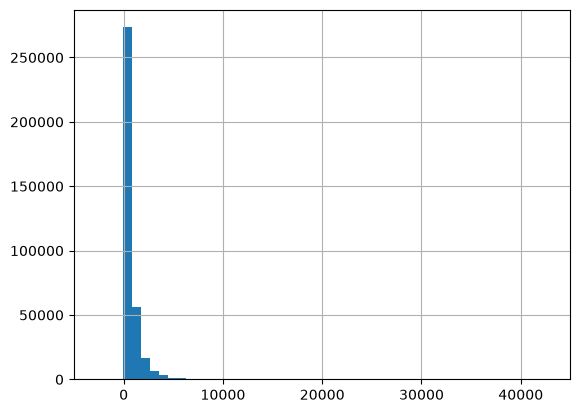

In [11]:
# Debemos calcular el ASL --> Average Session Length
visits['asl_sec'] = (visits['end_ts'] - visits['start_ts']).dt.total_seconds()

# Imprimimos las ASL de las sesiones
print('La cantidad de segundos por visita del usuario es la siguiente:')
print(visits['asl_sec'])
print('------------------------------------------------------------------------')

# Sin embargo, nos gustaría saber cuál es la moda, media y mediana; para entender el comportamiento de los clientes
print('El comportamiento de los clientes en cuanto a la duración de las sesiones es el siguiente:')
print(f'La media de segundos es: {visits["asl_sec"].mean():.2f}')
print(f'La mediana de segundos es: {visits["asl_sec"].median():.2f}')
print(f'La moda de segundos es: {visits["asl_sec"].mode()[0]}')
print('------------------------------------------------------------------------')

# Histograma para reflejar los resultados
visits['asl_sec'].hist(bins=50)

La información de la distribución de la duración de las sesiones es la siguiente:
count    359400.00
mean        643.03
std         997.13
min       -2760.00
25%         120.00
50%         300.00
75%         840.00
max       42660.00
Name: asl_sec, dtype: float64


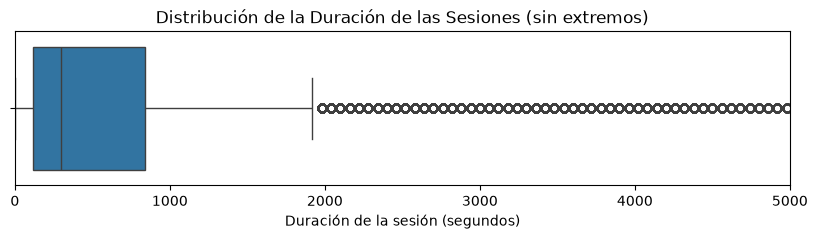

In [12]:
#Información dedistribución de la duración de las sesiones
print('La información de la distribución de la duración de las sesiones es la siguiente:')
print(visits['asl_sec'].describe().round(2))

# Visualización de la distribución de la duración de las sesiones sin valores extremos
plt.figure(figsize=(10,2))
sns.boxplot(
    x=visits['asl_sec']
)
plt.xlim(0, 5000)
plt.title('Distribución de la Duración de las Sesiones (sin extremos)')
plt.xlabel('Duración de la sesión (segundos)')
plt.show()

#### El mínimo negativo es una alerta de calidad de datos
Se identificaron registros con duraciones negativas de sesión, atribuibles a inconsistencias en las marcas temporales de inicio y término. Debido a que estos valores no representan comportamientos reales de los usuarios, fueron considerados anomalías y excluidos del análisis.

Esto normalmente ocurre porque:
* La fecha/hora de inicio (start_ts) es posterior a la fecha/hora de término (end_ts).
* Existen errores de registro en la base de datos.
* Problemas de sincronización de servidores.
* Registros corruptos o incompletos.

Finalmente, en un proyecto profesional de análisis de datos normalmente se eliminan este tipo de datos anómalos.

In [13]:
# Número de sesiones con duración negativa
num_negative_sessions = (visits['asl_sec'] < 0).sum()
print(f'Número de sesiones con duración negativa: {num_negative_sessions}')

# Identificar sesiones con duración negativa de forma específica para entender el comportamiento de los clientes
visits.loc[
    visits['asl_sec'] < 0,
    ['uid','start_ts','end_ts','asl_sec']
]



Número de sesiones con duración negativa: 2


,uid,start_ts,end_ts,asl_sec
4181,13092152539246794986,2018-03-25 03:50:00,2018-03-25 03:18:00,-1920.0
177972,4621202742905035453,2018-03-25 03:55:00,2018-03-25 03:09:00,-2760.0


In [14]:
# Eliminar sesiones con duración negativa para un análisis más preciso del comportamiento de los clientes
visits = visits[visits['asl_sec'] >= 0]
print(f'Número de sesiones después de eliminar las sesiones con duración negativa: {len(visits)}')

Número de sesiones después de eliminar las sesiones con duración negativa: 359398


#### Análisis de la Duración de las Sesiones
El histograma muestra una distribución asimétrica positiva (sesgada hacia la derecha), donde la mayoría de las sesiones se concentra en duraciones relativamente cortas. Sin embargo, existe una cola larga formada por sesiones de mayor duración, lo que indica que algunos usuarios permanecen significativamente más tiempo en la plataforma que el promedio general. El análisis de Boxplot de la duración de las sesiones muestra una distribución fuertemente asimétrica hacia la derecha. Mientras que el 50% de las sesiones dura menos de 5 minutos y el 75% menos de 14 minutos, existen numerosas sesiones extremadamente largas que elevan significativamente el promedio general hasta 643 segundos.

Este comportamiento sugiere que Showz es utilizada principalmente para consultas rápidas de información sobre eventos, aunque existe un grupo menor de usuarios que realiza una exploración más extensa del contenido disponible. El Boxplot evidencia una gran cantidad de valores atípicos ubicados por encima del límite superior esperado, lo que sugiere la presencia de usuarios que permanecieron largos períodos en la plataforma o registros asociados a sesiones abiertas durante varias horas. Esta situación explica por qué la media resulta considerablemente superior a la mediana.

Adicionalmente, se detectaron registros con duraciones negativas, lo que indica inconsistencias en las marcas temporales de inicio y término de algunas sesiones. Estos valores corresponden a anomalías de calidad de datos y deberían excluirse del análisis para evitar distorsiones en las métricas de comportamiento de los usuarios.

### Análisis de Recurrencia y Fidelización de Usuarios
Más allá de conocer cuántos usuarios visitan la plataforma, resulta fundamental analizar cuántos de ellos regresan posteriormente. La frecuencia de retorno permite evaluar el nivel de interés y compromiso generado por Showz, además de entregar señales sobre la capacidad de la plataforma para retener usuarios a lo largo del tiempo.

En esta sección se examina la cantidad de visitas realizadas por cada usuario con el objetivo de identificar patrones de recurrencia. Este análisis permitirá determinar si la plataforma es utilizada principalmente para consultas ocasionales o si existe un grupo de usuarios que regresa frecuentemente para explorar eventos y realizar nuevas interacciones.

In [15]:
# Contar las visitas por usuario
visits_per_user = visits.groupby('uid').size()

# Cantidad de usuarios por número de visitas
visits_distribution = visits_per_user.value_counts().sort_index()

# Crear categoría para más de 10 visitas
more_than_10 = visits_distribution[visits_distribution.index > 10].sum()

# Mantener 2-10 visitas
visits_distribution = visits_distribution[
    (visits_distribution.index >= 2) &
    (visits_distribution.index <= 10)
]

# Agregar categoría especial
visits_distribution.loc['>10'] = more_than_10

# Calcular porcentajes
distribution_df = pd.DataFrame({
    'usuarios': visits_distribution,
    'porcentaje (%)': round(
        visits_distribution / visits_distribution.sum() * 100,
        2
    )
})

print(distribution_df)

     usuarios  porcentaje (%)
2       30926           59.33
3       10184           19.54
4        4358            8.36
5        2282            4.38
6        1243            2.38
7         807            1.55
8         513            0.98
9         356            0.68
10        239            0.46
>10      1220            2.34


#### Recurrencia y Fidelización
El análisis muestra que la frecuencia de retorno disminuye progresivamente a medida que aumenta la cantidad de visitas realizadas por los usuarios. La mayoría de los usuarios recurrentes regresa únicamente una o dos veces después de su visita inicial, mientras que un grupo considerablemente menor mantiene una interacción constante con la plataforma.

Se observa que más de 30.000 usuarios realizaron exactamente dos visitas, convirtiéndose en el comportamiento recurrente más común. A partir de ese punto, la cantidad de usuarios disminuye de forma sostenida, lo que sugiere que la retención de largo plazo representa un desafío para la plataforma.

Asimismo, se identificó un segmento reducido de 135 usuarios que visitó la plataforma más de 10 veces durante el período analizado. Este grupo podría representar a los usuarios más comprometidos con Showz y constituye una oportunidad para estudiar sus características y comprender qué factores impulsan su alto nivel de interacción.

Los resultados indican que la plataforma logra atraer usuarios inicialmente, pero enfrenta dificultades para mantener su participación a largo plazo. La fuerte disminución en la frecuencia de visitas sugiere que la experiencia del usuario, el valor percibido o los mecanismos de retención podrían mejorarse para incrementar la recurrencia.

Para incrementar la recurrencia de los usuarios en la plataforma, podríamos utilizar herramientas tales como:
* Enviar email con recordatorios.
* Programas de fidelización.
* Mejorar la experiencia del usuario.

### Tiempo para la primera compra
En esta etapa se analiza el tiempo que transcurre entre la primera visita de un usuario a la plataforma y su primera compra. Este indicador permite comprender la velocidad con la que los usuarios convierten de visitantes a clientes, identificar los períodos más críticos para la toma de decisiones y evaluar la efectividad de la experiencia inicial ofrecida por la plataforma. Además, conocer estos patrones resulta fundamental para optimizar estrategias de marketing, remarketing y retención temprana.

In [16]:
# Momento que se ingresa por primera vez el usuario
first_visit = visits.groupby('uid')['start_ts'].min().reset_index()
first_visit.columns = ['uid', 'first_visit_date']

# Obtener la primera compra del usuario
first_order = orders.groupby('uid')['buy_ts'].min().reset_index()
first_order.columns = ['uid', 'first_order_date']

# Unir la primera visita y primera compra
conversion = first_visit.merge(first_order, on='uid')

# Calcular la diferencia de la visita y la compra
conversion['conversion_day'] = (conversion['first_order_date'] - conversion['first_visit_date']).dt.days



In [17]:
# Creación de DataFrame para agrupar las conversiones por día
conversion_groups = pd.DataFrame({
    'conversiones': [
        (conversion['conversion_day'] == 0).sum(),
        (conversion['conversion_day'] == 1).sum(),
        (conversion['conversion_day'] == 2).sum(),
        (conversion['conversion_day'] == 3).sum(),
        (conversion['conversion_day'] == 4).sum(),
        (conversion['conversion_day'] == 5).sum(),
        (conversion['conversion_day'] == 6).sum(),
        (conversion['conversion_day'] == 7).sum(),
        ((conversion['conversion_day'] > 7) &
         (conversion['conversion_day'] <= 30)).sum(),
        ((conversion['conversion_day'] > 30) &
         (conversion['conversion_day'] <= 90)).sum(),
        (conversion['conversion_day'] > 90).sum()
    ]
},
index=[
    'Mismo día',
    '1 día',
    '2 días',
    '3 días',
    '4 días',
    '5 días',
    '6 días',
    '7 días',
    '8-30 días',
    '31-90 días',
    '>90 días'
])

# Crear columna de porcentaje
conversion_groups['porcentaje'] = round(
    conversion_groups['conversiones']
    / conversion_groups['conversiones'].sum()
    * 100,
    2
)

print(conversion_groups)

            conversiones  porcentaje
Mismo día          26363       72.18
1 día               1011        2.77
2 días               563        1.54
3 días               434        1.19
4 días               324        0.89
5 días               270        0.74
6 días               260        0.71
7 días               218        0.60
8-30 días           2178        5.96
31-90 días          2274        6.23
>90 días            2628        7.20


<Axes: >

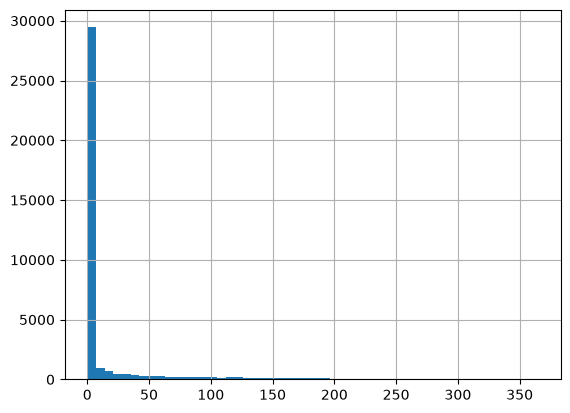

In [18]:
# Creación de Histograma de Tiempo de Primera compras
conversion['conversion_day'].hist(bins=52, range=(0,365))

#### Análisis de tiempo de la primera compra
El análisis del tiempo transcurrido entre la primera visita y la primera compra muestra que la conversión ocurre principalmente de forma inmediata. Aproximadamente el 72% de los usuarios realiza su primera compra el mismo día en que visita la plataforma por primera vez, lo que indica que la experiencia inicial y las estrategias de captación tienen un impacto directo en la generación de ventas.

A medida que transcurren los días, la probabilidad de conversión disminuye considerablemente. Las conversiones realizadas durante la primera semana representan una proporción significativamente menor en comparación con las compras efectuadas el mismo día. Sin embargo, existe un grupo de usuarios que requiere más tiempo para tomar la decisión de compra, observándose conversiones incluso después de 90 días desde la primera visita.

Estos resultados sugieren que los primeros días de interacción constituyen la ventana más importante para convertir visitantes en clientes. Por ello, las acciones de marketing, promociones personalizadas y campañas de remarketing deberían concentrarse especialmente durante este período para maximizar la tasa de conversión.

### Análisis de Frecuencia de Pedidos
Una vez identificado cuándo los usuarios realizan su primera compra, resulta relevante analizar la frecuencia con la que se generan pedidos dentro de la plataforma. Este análisis permite evaluar el nivel de actividad comercial de Showz, identificar patrones temporales de demanda y comprender cómo evoluciona el volumen de ventas a lo largo del tiempo.

Para ello, se estudiará la cantidad de pedidos realizados en diferentes escalas temporales —diaria, semanal y mensual— calculando medidas descriptivas como promedio, mediana, máximos y mínimos. Estos indicadores permitirán evaluar la estabilidad de las ventas, detectar posibles fluctuaciones estacionales y generar una base sólida para posteriores análisis de ingresos y rentabilidad.

In [ ]:
# Pedidos por día
order_per_day = orders.groupby(orders['buy_ts'].dt.date).size()

print('Frecuencia de pedidos por día:')
print(order_per_day)
print()

print('Variables Estadísticas de la cantidad de pedidos por día:')
print(f'- Promedio: {order_per_day.mean().round(1)} pedidos')
print(f'- Mediana: {order_per_day.median()} pedidos')
print(f'- Moda: {order_per_day.mode()[0]} pedidos')

Frecuencia de pedidos por día:
buy_ts
2017-06-01     96
2017-06-02    111
2017-06-03     67
2017-06-04     66
2017-06-05    161
             ... 
2018-05-28    188
2018-05-29    189
2018-05-30    208
2018-05-31    610
2018-06-01      1
Length: 364, dtype: int64

Variables Estadísticas de la cantidad de pedidos por día:
- Promedio: 138.5 pedidos
- Mediana: 136.0 pedidos
- Moda: 155 pedidos


In [30]:
# Pedidos por semanas
orders['week_start'] = orders['buy_ts'].dt.to_period('W').apply(lambda x: x.start_time)

order_per_week = orders.groupby('week_start').size()

print('Frecuencia de pedidos por semana:')
print(order_per_week)

print(' Variables Estadísticas de la frecuencia de pedidos por semana:')
print(f'Promedio: {order_per_week.mean():.1f} pedidos')
print(f'Mediana: {order_per_week.median():.0f} pedidos')
print(f'Moda: {order_per_week.mode()[0]:.0f} pedidos')

Frecuencia de pedidos por semana:
week_start
2017-05-29     340
2017-06-05     938
2017-06-12     343
2017-06-19     371
2017-06-26     460
2017-07-03     477
2017-07-10     636
2017-07-17     716
2017-07-24     381
2017-07-31     314
2017-08-07     325
2017-08-14     392
2017-08-21     480
2017-08-28     588
2017-09-04     666
2017-09-11     668
2017-09-18     826
2017-09-25    1110
2017-10-02    1666
2017-10-09    1270
2017-10-16    1140
2017-10-23    1132
2017-10-30    1059
2017-11-06     919
2017-11-13    1257
2017-11-20    1894
2017-11-27    1387
2017-12-04    1520
2017-12-11    1388
2017-12-18    1184
2017-12-25    1620
2018-01-01    1006
2018-01-08     942
2018-01-15     991
2018-01-22    1128
2018-01-29    1442
2018-02-05    1272
2018-02-12    1368
2018-02-19    1347
2018-02-26    1252
2018-03-05    1293
2018-03-12    1007
2018-03-19    1418
2018-03-26     862
2018-04-02     733
2018-04-09     698
2018-04-16     890
2018-04-23     890
2018-04-30     547
2018-05-07     635
2018-

In [31]:
# Pedidos por meses
orders['buy_month'] = orders['buy_ts'].dt.to_period('M')
orders['buy_year'] = orders['buy_ts'].dt.isocalendar().year

order_per_month_year = orders.pivot_table(
    index='buy_month',
    columns='buy_year',
    values='uid',
    aggfunc='count'
)

order_per_month_year = order_per_month_year.fillna(0)
print('Frecuencia de pedidos por mes y año:')
print(order_per_month_year)
print()

order_per_month = orders.pivot_table(
    index='buy_month',
    values='uid',
    aggfunc='count'
)

monthly_orders = order_per_month.stack()

monthly_orders_clean = monthly_orders.iloc[:-1]

print('Variables Estadísticas de la frecuencia de pedidos por mes:')
print(f'- Promedio: {monthly_orders_clean.mean():.2f} pedidos')
print(f'- Mediana: {monthly_orders_clean.median():.2f} pedidos')
print(f'- Moda: {monthly_orders_clean.mode()[0]} pedidos')

Frecuencia de pedidos por mes y año:
buy_year     2017    2018
buy_month                
2017-06    2354.0     0.0
2017-07    2363.0     0.0
2017-08    1807.0     0.0
2017-09    3387.0     0.0
2017-10    5679.0     0.0
2017-11    5659.0     0.0
2017-12    6218.0     0.0
2018-01       0.0  4721.0
2018-02       0.0  5281.0
2018-03       0.0  5326.0
2018-04       0.0  3273.0
2018-05       0.0  4346.0
2018-06       0.0     1.0

Variables Estadísticas de la frecuencia de pedidos por mes:
- Promedio: 4201.17 pedidos
- Mediana: 4533.50 pedidos
- Moda: 1807 pedidos


#### Análisis sobre frecuencias de pedidos
**Frecuencia diaria**
* La plataforma registra en promedio 138 pedidos diarios, con una mediana de 136 pedidos y una moda de 155 pedidos. La cercanía entre la media y la mediana indica una distribución relativamente estable de pedidos diarios, sin una influencia excesiva de valores atípicos. Esto sugiere una demanda consistente a lo largo del período analizado.

**Frecuencia semanal**
* Al agrupar los pedidos por semanas utilizando la fecha de inicio de cada período semanal, se observa un promedio de 951 pedidos por semana y una mediana de 991 pedidos. La similitud entre ambas métricas indica una actividad comercial relativamente estable, aunque existen algunas semanas con volúmenes significativamente superiores que elevan ligeramente la dispersión de los datos.
* Se aprecia además una tendencia creciente durante gran parte del período analizado, pasando desde aproximadamente 300–900 pedidos semanales en las primeras semanas hasta superar los 1.500 pedidos semanales en algunos momentos, lo que podría indicar un crecimiento sostenido de la plataforma o una mejora en la adquisición de clientes.

**Frecuencia mensual**
* El análisis mensual muestra un incremento progresivo en el volumen de pedidos durante el período de estudio. Mientras los primeros meses registran alrededor de 2.000–3.000 pedidos, hacia finales de 2017 y comienzos de 2018 se observan volúmenes superiores a los 5.000 pedidos mensuales.
* Este comportamiento sugiere una expansión de la actividad comercial y una mayor adopción de la plataforma por parte de los usuarios.
* Es importante señalar que junio de 2018 presenta únicamente un pedido registrado, debido a que el conjunto de datos finaliza el primer día de dicho mes. Por esta razón, dicho período debe considerarse incompleto y no resulta representativo para evaluar el comportamiento mensual real.


### Pedidos Mensuales por Tipo de Dispositivo
En esta sección se analiza cómo se distribuyen los pedidos mensuales según el tipo de dispositivo utilizado por los usuarios. Esta segmentación permite identificar si las compras se concentran principalmente en usuarios de escritorio o móviles, y evaluar si existen diferencias relevantes en el comportamiento de compra entre canales.

Comprender el peso de cada dispositivo es importante para orientar decisiones de marketing, experiencia de usuario y optimización de la plataforma, especialmente si uno de los canales concentra una mayor proporción de pedidos o muestra una evolución más favorable en el tiempo.

In [34]:
# Unir los pedidos por usuario con un dispositivo asociado
orders_device = orders.merge(visits, on='uid', how='left')

# Creación de columna de mes de compra
orders_device['buy_month'] = orders_device['buy_ts'].dt.to_period('M')

# Tabla comparativa por pedidos por mes y device
orders_per_month_device = orders_device.pivot_table(
    index='buy_month',
    columns='device',
    values='uid',
    aggfunc='count',
    fill_value=0
)

print('Pedidos por mes y dispositivo:')
print()
print(orders_per_month_device)

Pedidos por mes y dispositivo:

device     desktop  touch
buy_month                
2017-06      24330   1509
2017-07      32432   1937
2017-08      34575   1271
2017-09      62715   2441
2017-10      67711   5912
2017-11      61178   6946
2017-12      95830   5484
2018-01      65799   3915
2018-02      87014   4288
2018-03      72998   7028
2018-04      49645   3604
2018-05      58964   4280
2018-06          1      0


In [37]:
# Variables Estadísticas mensual por dispositivo

orders_per_month_device_clean = orders_per_month_device.iloc[:-1]

print('Variables Estadísticas de pedidos por dispositivo mensual:')
print(f'- Promedio: {orders_per_month_device_clean.mean().round(2)}')
print(f'- Mediana: {orders_per_month_device_clean.median()}')
print(f'- Moda: {orders_per_month_device_clean.mode().iloc[0]}')

Variables Estadísticas de pedidos por dispositivo mensual:
- Promedio: device
desktop    59432.58
touch       4051.25
dtype: float64
- Mediana: device
desktop    61946.5
touch       4097.5
dtype: float64
- Moda: device
desktop    24330
touch       1271
Name: 0, dtype: int64


<Axes: title={'center': 'Pedidos por mes según dispositivo'}, xlabel='Mes de compra', ylabel='Cantidad de pedidos'>

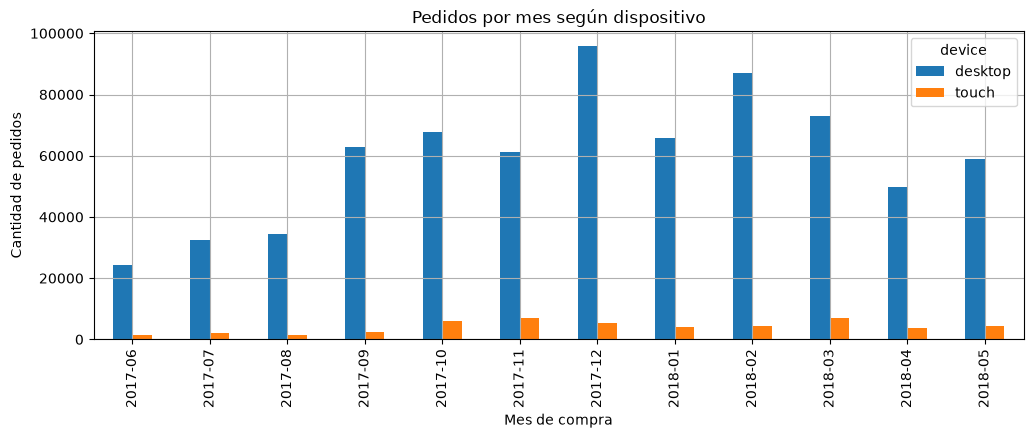

In [39]:
# Gráfico para observar si existe estacionalidad
orders_per_month_device_clean.plot(
    kind='bar',
    figsize=(12, 4),
    title='Pedidos por mes según dispositivo',
    xlabel='Mes de compra',
    ylabel='Cantidad de pedidos',
    grid=True
)

#### Análisis de pedidos mensuales por dispositivo
1. Desktop concentra la gran mayoría de los pedidos.
Durante todo el período analizado, los usuarios que acceden desde desktop generan significativamente más pedidos que los usuarios touch, representando aproximadamente entre el 85% y 95% del volumen total mensual.

Esto sugiere que la plataforma Showz es utilizada principalmente desde computadores para completar las compras, probablemente debido a una mejor experiencia de navegación, búsqueda de eventos o proceso de pago.

2. Existe una tendencia similar entre ambos dispositivos
Aunque desktop domina ampliamente el volumen de pedidos, ambos dispositivos muestran patrones de crecimiento y disminución similares a lo largo del tiempo.

Por ejemplo:
* Incremento importante entre septiembre y diciembre de 2017.
* Pico máximo en diciembre de 2017.
* Descenso durante enero y abril de 2018.
* Recuperación parcial durante febrero, marzo y mayo de 2018.

Esto indica que las variaciones observadas parecen responder más a factores de negocio o estacionalidad de eventos que al tipo de dispositivo utilizado.

3. Diciembre presenta el mayor nivel de actividad comercial
El mes de diciembre de 2017 registra el mayor volumen de pedidos para ambos dispositivos:
* Desktop: aproximadamente 95.830 pedidos.
* Touch: aproximadamente 5.484 pedidos.

Este comportamiento podría estar relacionado con:
* Eventos de fin de año.
* Mayor actividad de ocio.
* Compras anticipadas para festividades.
* Campañas promocionales.
4. Los usuarios móviles representan una oportunidad de crecimiento
A pesar de que touch mantiene una participación considerablemente menor, se observa presencia constante durante todo el período.

Las medianas mensuales muestran:
* Desktop: ~61.947 pedidos.
* Touch: ~4.098 pedidos.

La diferencia evidencia que existe margen para mejorar la experiencia móvil y aumentar las conversiones desde estos dispositivos.

5. La distribución mensual es relativamente estable
Las medias y medianas son bastante cercanas. Esto indica que, aunque existen algunos picos de demanda, el comportamiento general es relativamente estable y no está excesivamente influenciado por valores extremos.

### Valor de Compra e Ingresos Generados por los Clientes
Después de comprender cómo los usuarios utilizan la plataforma y con qué frecuencia realizan pedidos, resulta fundamental analizar el valor económico de dichas compras. En esta etapa se evaluará el tamaño promedio de los pedidos realizados en Showz, identificando diferencias temporales y comportamientos según dispositivo.

Además, se estudiará el ingreso promedio generado por usuario, lo que permitirá estimar el aporte económico de cada cliente y sentar las bases para el análisis posterior de rentabilidad, costo de adquisición (CAC) y retorno sobre la inversión en marketing (ROMI).

In [40]:
# La orden promedio de compra
avg_buy_size = orders['revenue'].mean()
print(f'Tamaño promedio de compra: {avg_buy_size:.2f}')

Tamaño promedio de compra: 5.00


In [44]:
# El tamaño de compra mensual
avg_buy_month = orders.pivot_table(
    index='buy_month',
    values='revenue',
    aggfunc='mean'
)

# Exclusión del mes incompleto de los datos para un análisis más preciso -> 06-2018
avg_buy_month_clean = avg_buy_month.iloc[:-1]

print('Tamaño de compra por usuario mensual:')
print(avg_buy_month_clean.round(2))

Tamaño de compra por usuario mensual:
           revenue
buy_month         
2017-06       4.06
2017-07       5.31
2017-08       4.85
2017-09       5.42
2017-10       4.93
2017-11       4.78
2017-12       5.85
2018-01       4.11
2018-02       4.84
2018-03       5.41
2018-04       5.15
2018-05       4.77


In [46]:
# Tamaño de compra por dispositivo
avg_buy_device = orders_device.pivot_table(
    index='device',
    values='revenue',
    aggfunc='mean'
)
print('Tamaño de compra por dispositivo:')
print(avg_buy_device.round(2))

Tamaño de compra por dispositivo:
         revenue
device          
desktop     9.04
touch      10.58


In [57]:
# Tamaño de la compra por usuario
revenue_per_user = orders.groupby('uid')['revenue'].sum()

avg_revenue_per_user = revenue_per_user.mean()

print(f'Ingreso promedio por usuario: {avg_revenue_per_user:.2f}')
print(f'Mediana ingreso promedio por usuario: {revenue_per_user.median():.2f}')
print()

print(f'Promedio de compra: {orders["revenue"].mean():.2f}')
print(f'Mediana de compra: {orders["revenue"].median():.2f}')
print()

print(orders['revenue'].describe().round(2))

Ingreso promedio por usuario: 6.90
Mediana ingreso promedio por usuario: 3.05

Promedio de compra: 5.00
Mediana de compra: 2.50

count    50415.00
mean         5.00
std         21.82
min          0.00
25%          1.22
50%          2.50
75%          4.89
max       2633.28
Name: revenue, dtype: float64


#### Análisis de Valor de compra e Ingresos
1. El ticket promedio de compra es relativamente bajo
El valor promedio por pedido es de 5.00 unidades monetarias, lo que indica que los usuarios suelen realizar compras de bajo valor individual. Esto sugiere que el modelo de negocio depende más de la frecuencia de compra y del volumen de clientes que de transacciones de alto valor.

2. El tamaño de compra se mantiene estable durante el período analizado
El ticket promedio mensual oscila entre 4.06 y 5.85, mostrando variaciones moderadas a lo largo del tiempo.
* Mínimo ticket promedio: 4.06
* Máximo ticket promedio: 5.85
Esto indica que el comportamiento de gasto por pedido es relativamente consistente y no presenta cambios drásticos entre meses.

3. Diciembre presenta el mayor valor promedio por pedido
Durante diciembre de 2017 se registra el ticket promedio más alto (5.85), posiblemente asociado a factores estacionales como promociones, festividades o un mayor nivel de consumo durante el cierre del año.

4. Los usuarios móviles realizan compras de mayor valor
El ticket promedio por dispositivo muestra diferencias relevantes:
* Desktop ticket promedio: 9.04
* Touch ticket promedio: 10.58
Los usuarios que compran desde dispositivos móviles generan compras aproximadamente un 17% superiores a las realizadas desde escritorio. Esto puede indicar que:
* Los usuarios móviles tienen una intención de compra más definida.
* La experiencia móvil está funcionando correctamente.
* Existe una oportunidad para fortalecer campañas orientadas a dispositivos móviles.

5. El ingreso promedio por usuario supera ampliamente la mediana
La métrica es la siguiente:
* Promedio ingreso por usuario: 6.90
* Mediana ingreso por usuario: 3.05
Un pequeño grupo de usuarios genera una parte importante de los ingresos totales, elevando el promedio general. Este comportamiento es muy común en negocios digitales y suele responder al principio de Pareto (80/20).

6. Existen compras extremadamente altas que influyen en la media
Los estadísticos descriptivos muestran:
* Mediana: 2.50
* Percentil: 4.89
* Máximo: 2633.28
La existencia de pedidos de hasta 2633.28 confirma la presencia de valores atípicos muy elevados. Por lo tanto, el ticket promedio de 5.00 está influenciado por un grupo reducido de compras excepcionalmente grandes.

En conclusión, el análisis del tamaño de compra muestra que Showz opera principalmente con transacciones de bajo valor individual, manteniendo un ticket promedio cercano a 5 unidades monetarias durante todo el período estudiado. Sin embargo, la distribución de ingresos presenta una fuerte asimetría debido a la existencia de clientes y compras de alto valor que elevan significativamente el promedio general. Asimismo, los usuarios que compran desde dispositivos móviles generan tickets promedio superiores a los de escritorio, lo que sugiere una oportunidad para potenciar la experiencia móvil y las estrategias de adquisición dirigidas a este segmento. En conjunto, los resultados indican que el crecimiento de los ingresos depende tanto de aumentar la frecuencia de compra como de potenciar la retención de los clientes con mayor valor económico.

## Análisis del Valor del Cliente (LTV)
Una vez analizados el comportamiento de compra, la frecuencia de pedidos y el tamaño promedio de las transacciones, resulta fundamental determinar cuánto valor económico aporta cada usuario a la empresa durante su relación con la plataforma.

Para ello, se calculará el **Lifetime Value (LTV)** mediante un análisis de cohortes. Este enfoque permite agrupar usuarios según el mes de su primera visita y evaluar cómo evolucionan los ingresos generados por cada grupo a lo largo del tiempo.

El objetivo es identificar qué cohortes generan mayores ingresos, cuánto tardan en monetizarse y cómo evoluciona el valor acumulado de los clientes desde su incorporación a la plataforma. Estos resultados serán fundamentales para posteriormente comparar el LTV con los costos de adquisición (CAC) y evaluar la rentabilidad de las estrategias de marketing.

**Objetivo del análisis:**
* Calcular el ingreso promedio generado por usuario para cada cohorte.
* Analizar la evolución del valor económico de los clientes a través del tiempo.
* Identificar cohortes con mejor desempeño económico.
* Evaluar la velocidad con que los usuarios generan ingresos.
* Generar la base necesaria para el análisis de rentabilidad (ROMI).

In [58]:
# Crear cohorte (registro y compra)
first_visit['cohort_month'] = first_visit['first_visit_date'].dt.to_period('M')
orders['order_month'] = orders['buy_ts'].dt.to_period('M')

# Unir visitas y pedidos
cohort = first_visit.merge(orders, on='uid', how='left')
cohort = cohort.dropna(subset=['order_month'])

# Crear columna con cálculo de meses de cohorte
cohort['lifetime'] = (cohort['order_month'] - cohort['cohort_month']).apply(lambda x: x.n)

# Calcular ingresos por cohorte y tiempo
revenue_cohort = cohort.groupby(['cohort_month', 'lifetime'])['revenue'].sum().reset_index()

# Número de usuarios por cohorte
cohort_size = first_visit.groupby('cohort_month')['uid'].nunique()

In [61]:
# Cálculo de LTV
revenue_cohort['cohort_size'] = revenue_cohort['cohort_month'].map(cohort_size)

revenue_cohort['ltv'] = (revenue_cohort['revenue'] / revenue_cohort['cohort_size'])

ltv_table = revenue_cohort.pivot_table(
    index='cohort_month',
    columns='lifetime',
    values='ltv',
    aggfunc='sum'
)

ltv_table = ltv_table.round(2)

print('Tabla Pivote - LTV:')
print()
print(ltv_table)

Tabla Pivote - LTV:

lifetime        0     1     2     3     4     5     6     7     8     9   \
cohort_month                                                               
2017-06       0.72  0.20  0.11  0.29  0.30  0.21  0.26  0.17  0.17  0.26   
2017-07       0.75  0.08  0.08  0.07  0.06  0.06  0.04  0.06  0.06  0.04   
2017-08       0.61  0.10  0.10  0.09  0.08  0.05  0.05  0.12  0.08  0.04   
2017-09       0.74  0.22  0.13  0.62  0.08  0.11  0.06  0.03  0.03   NaN   
2017-10       0.71  0.15  0.05  0.04  0.04  0.04  0.02  0.03   NaN   NaN   
2017-11       0.61  0.10  0.05  0.05  0.04  0.03  0.03   NaN   NaN   NaN   
2017-12       0.67  0.07  0.17  0.20  0.06  0.07   NaN   NaN   NaN   NaN   
2018-01       0.47  0.09  0.05  0.01  0.02   NaN   NaN   NaN   NaN   NaN   
2018-02       0.52  0.09  0.03  0.04   NaN   NaN   NaN   NaN   NaN   NaN   
2018-03       0.58  0.05  0.04   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2018-04       0.51  0.12   NaN   NaN   NaN   NaN   NaN   NaN   NaN 

In [63]:
# Tabla LTV Acumulativo
ltv_cumulative = ltv_table.cumsum(axis=1)

print('Tabla Pivote - LTV Acumulativo:')
print()
print(ltv_cumulative)

Tabla Pivote - LTV Acumulativo:

lifetime        0     1     2     3     4     5     6     7     8     9   \
cohort_month                                                               
2017-06       0.72  0.92  1.03  1.32  1.62  1.83  2.09  2.26  2.43  2.69   
2017-07       0.75  0.83  0.91  0.98  1.04  1.10  1.14  1.20  1.26  1.30   
2017-08       0.61  0.71  0.81  0.90  0.98  1.03  1.08  1.20  1.28  1.32   
2017-09       0.74  0.96  1.09  1.71  1.79  1.90  1.96  1.99  2.02   NaN   
2017-10       0.71  0.86  0.91  0.95  0.99  1.03  1.05  1.08   NaN   NaN   
2017-11       0.61  0.71  0.76  0.81  0.85  0.88  0.91   NaN   NaN   NaN   
2017-12       0.67  0.74  0.91  1.11  1.17  1.24   NaN   NaN   NaN   NaN   
2018-01       0.47  0.56  0.61  0.62  0.64   NaN   NaN   NaN   NaN   NaN   
2018-02       0.52  0.61  0.64  0.68   NaN   NaN   NaN   NaN   NaN   NaN   
2018-03       0.58  0.63  0.67   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2018-04       0.51  0.63   NaN   NaN   NaN   NaN   NaN 

In [64]:
# Identificar la mejor cohorte y su LTV acumulado máximo
best_cohort = ltv_cumulative.iloc[:,-1].idxmax()
best_ltv = ltv_cumulative.iloc[:,-1].max()

print(f'Mejor cohorte: {best_cohort}')
print(f'LTV acumulado máximo: {best_ltv:.2f}')

Mejor cohorte: 2017-06
LTV acumulado máximo: 3.01


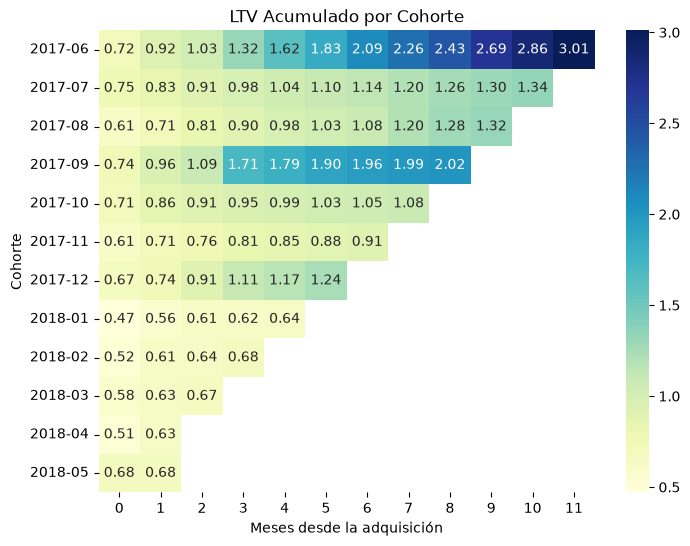

In [ ]:
# Creación de Heatmap para visualizar el LTV acumulado por cohorte
plt.figure(figsize=(8,6))

sns.heatmap(
    ltv_cumulative,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('LTV Acumulado por Cohorte')
plt.xlabel('Meses desde la adquisición')
plt.ylabel('Cohorte')
plt.show()

### Análisis LTV
El análisis de cohortes revela diferencias significativas en la capacidad de monetización de los usuarios adquiridos en distintos períodos. La cohorte de junio de 2017 registró el mayor LTV acumulado, alcanzando un valor de 3.01 unidades monetarias por usuario, posicionándose como la cohorte más rentable del período analizado.

En términos generales, la mayor parte de los ingresos se genera durante los primeros meses posteriores a la adquisición, observándose posteriormente una desaceleración en el crecimiento del LTV. Asimismo, las cohortes incorporadas durante 2018 muestran niveles de monetización inferiores a las cohortes de 2017, lo que podría indicar cambios en la calidad del tráfico adquirido o en el comportamiento de compra de los usuarios.

Estos resultados sugieren que las acciones de marketing deberían enfocarse en replicar las características de las cohortes más exitosas y en optimizar las estrategias de adquisición recientes para incrementar el valor generado por usuario a lo largo de su ciclo de vida.

### Análisis de Inversión en Marketing y Costos de Adquisición
Una vez analizado el comportamiento de los usuarios, la frecuencia de compra y el valor generado por los clientes a lo largo del tiempo (LTV), resulta necesario evaluar la inversión realizada por Showz para adquirir dichos usuarios.

En esta etapa se estudiarán los gastos de marketing desde distintas perspectivas: el gasto total del período, la distribución de la inversión entre las diferentes fuentes de adquisición y la evolución temporal de los costos. Este análisis permitirá identificar cuáles canales concentran una mayor proporción del presupuesto y servirá como base para calcular indicadores clave como el Costo de Adquisición de Clientes (CAC) y el Retorno sobre la Inversión en Marketing (ROMI).

Comprender cómo se distribuyen los recursos de marketing es fundamental para determinar si la inversión realizada está generando un retorno adecuado y para optimizar futuras estrategias de captación de usuarios.

**Objetivos del análisis**:
* Calcular el gasto total de marketing durante el período estudiado.
* Identificar las fuentes de adquisición que reciben mayor inversión.
* Analizar la evolución mensual de los costos.
* Comparar la distribución del presupuesto entre canales.
* Generar la base para el cálculo posterior de CAC y ROMI.

In [67]:
# Costo total del periodo estudiado
total_costs = costs['costs'].sum()
print(f'Gasto total del periodo analizado: {total_costs:.2f} unidades monetarias')

Gasto total del periodo analizado: 329131.62 unidades monetarias


In [70]:
# Costo por Fuente de Adqusición en orden descendente
costs_source = costs.groupby('source_id')['costs'].sum().sort_values(ascending=False)
print('Gasto por Fuente de Adqusición:')
print()
print(costs_source)

Gasto por Fuente de Adqusición:

source_id
3     141321.63
4      61073.60
5      51757.10
2      42806.04
1      20833.27
10      5822.49
9       5517.49
Name: costs, dtype: float64


Proporciones de Gastos por Fuente de Adquisición (en %):
source_id
3     42.94
4     18.56
5     15.73
2     13.01
1      6.33
10     1.77
9      1.68
Name: costs, dtype: float64


<Axes: title={'center': 'Distribución del gasto por fuente de adquisición'}, xlabel='Porcentaje (%)', ylabel='Fuente de adquisición'>

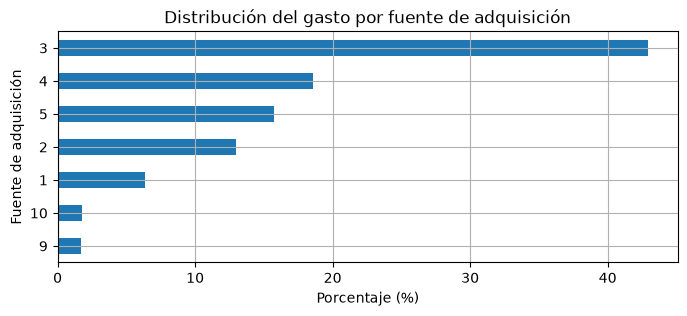

In [73]:
# Proporción del Total
percentage_costs_source = (costs_source / total_costs) * 100

print('Proporciones de Gastos por Fuente de Adquisición (en %):')
print(percentage_costs_source.round(2))

percentage_costs_source.sort_values().plot(
    kind='barh',
    figsize=(8,3),
    title='Distribución del gasto por fuente de adquisición',
    xlabel='Porcentaje (%)',
    ylabel='Fuente de adquisición',
    grid=True
)

In [75]:
# Gasto a lo largo del tiempo
costs['month'] = costs['dt'].dt.to_period('M')

costs_monthly = costs.groupby('month')['costs'].sum()

print('Gastos por Adquisición Mensuales:')
print(costs_monthly)
print()

print('Variables Estadísticas de los gastos por adquisición mensuales:')
print(f'- Promedio mensual: {costs_monthly.mean():.2f} unidades monetarias')
print(f'- Mediana mensual: {costs_monthly.median():.2f} unidades monetarias')
print(f'- Máximo mensual: {costs_monthly.max():.2f} unidades monetarias')
print(f'- Mínimo mensual: {costs_monthly.min():.2f} unidades monetarias')

Gastos por Adquisición Mensuales:
month
2017-06    18015.00
2017-07    18240.59
2017-08    14790.54
2017-09    24368.91
2017-10    36322.88
2017-11    37907.88
2017-12    38315.35
2018-01    33518.52
2018-02    32723.03
2018-03    30415.27
2018-04    22289.38
2018-05    22224.27
Freq: M, Name: costs, dtype: float64

Variables Estadísticas de los gastos por adquisición mensuales:
- Promedio mensual: 27427.63 unidades monetarias
- Mediana mensual: 27392.09 unidades monetarias
- Máximo mensual: 38315.35 unidades monetarias
- Mínimo mensual: 14790.54 unidades monetarias


Gastos por Fuente de Adqusición Mensuales:
source_id       1        2         3        4        5       9       10
month                                                                  
2017-06    1125.61  2427.38   7731.65  3514.80  2616.12  285.22  314.22
2017-07    1072.88  2333.11   7674.37  3529.73  2998.14  302.54  329.82
2017-08     951.81  1811.05   6143.54  3217.36  2185.28  248.93  232.57
2017-09    1502.01  2985.66   9963.55  5192.26  3849.14  415.62  460.67
2017-10    2315.75  4845.00  15737.24  6420.84  5767.40  609.41  627.24
2017-11    2445.16  5247.68  17025.34  5388.82  6325.34  683.18  792.36
2017-12    2341.20  4897.80  16219.52  7680.47  5872.52  657.98  645.86
2018-01    2186.18  4157.74  14808.78  5832.79  5371.52  547.16  614.35
2018-02    2204.48  4474.34  14228.56  5711.96  5071.31  551.50  480.88
2018-03    1893.09  3943.14  13080.85  5961.87  4529.62  480.29  526.41
2018-04    1327.49  2993.70   9296.81  4408.49  3501.15  373.49  388.25
2018-05    1467.61  2

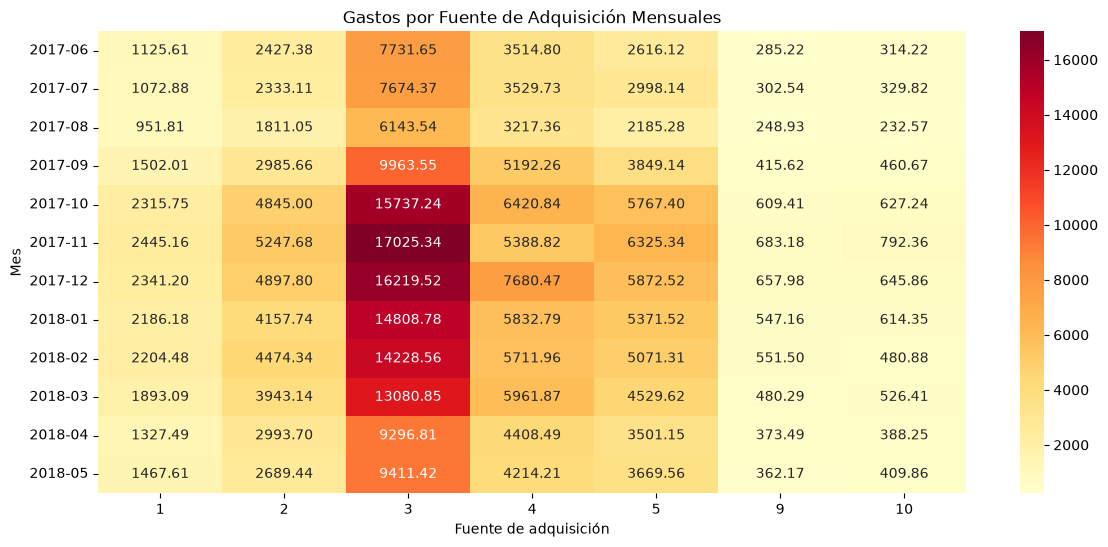

In [79]:
# Gasto a lo largo del tiempo por Fuente de Adqusición
costs_source_monthly = costs.pivot_table(
    index='month',
    columns='source_id',
    values='costs',
    aggfunc='sum'
)

print('Gastos por Fuente de Adqusición Mensuales:')
print(costs_source_monthly.round(2))

plt.figure(figsize=(14,6))
sns.heatmap(
    costs_source_monthly,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd'
)
plt.title('Gastos por Fuente de Adquisición Mensuales')
plt.xlabel('Fuente de adquisición')
plt.ylabel('Mes')
plt.show()

#### Análisis de Inversión en Marketing y Costos de Adquisición
Durante el período analizado, Showz invirtió un total de 329.131,62 unidades monetarias en actividades de adquisición de usuarios. Esta inversión constituye la base para evaluar posteriormente la eficiencia de cada canal mediante métricas como CAC y ROMI.

La distribución del presupuesto muestra una fuerte concentración en la fuente de adquisición 3, la cual absorbe el 42,94% de toda la inversión realizada. Esta cifra es superior a la suma de varias fuentes menores y evidencia que la empresa considera este canal como su principal vía de captación de usuarios. Las fuentes 4 y 5 representan el segundo y tercer nivel de inversión, acumulando conjuntamente un 34,29% del presupuesto total. En contraste, las fuentes 9 y 10 reciben menos del 2% cada una, lo que indica una participación marginal dentro de la estrategia de marketing. Por lo tanto, las cuatro principales fuentes (3, 4, 5 y 2) concentran aproximadamente el 90% del presupuesto total de marketing, lo que refleja una estrategia altamente focalizada en un número reducido de canales. Esto aumenta la dependencia de estos medios y hace especialmente relevante evaluar su rentabilidad individual.

El gasto en marketing presenta una tendencia creciente desde septiembre de 2017 hasta diciembre de 2017, alcanzando su máximo histórico en diciembre con una inversión de 38.315 unidades monetarias. A partir de enero de 2018 se observa una reducción gradual del presupuesto, aunque los niveles de inversión continúan siendo superiores a los registrados durante los primeros meses analizados.

La mayor intensidad de inversión se concentra entre octubre de 2017 y febrero de 2018. Este comportamiento podría estar asociado a campañas estacionales, promociones de fin de año o estrategias específicas orientadas a incrementar la captación de usuarios durante períodos de alta demanda.

El análisis de los gastos de marketing revela una estrategia de adquisición altamente concentrada, donde la fuente 3 representa casi la mitad de toda la inversión realizada. Asimismo, se observa una marcada intensificación del gasto durante el último trimestre de 2017 y comienzos de 2018, seguida de una reducción gradual en los meses posteriores. Estos resultados sugieren que la empresa prioriza un conjunto reducido de canales para captar usuarios, por lo que la siguiente etapa consistirá en evaluar la rentabilidad de cada fuente mediante indicadores como CAC, LTV y ROMI, con el fin de determinar si la distribución actual del presupuesto está generando el retorno esperado.

## Análisis del Costo de Adquisición de Clientes (CAC)
Después de analizar la distribución del gasto de marketing, es necesario evaluar qué tan eficiente fue dicha inversión para atraer nuevos clientes. Para ello, se calculará el Costo de Adquisición de Clientes (CAC), indicador que representa cuánto dinero debe invertir la empresa para conseguir un cliente a través de cada fuente de adquisición.

Este análisis permitirá comparar la eficiencia de los distintos canales de marketing, identificar cuáles generan clientes a menor costo y establecer una base para posteriores métricas de rentabilidad, como el Lifetime Value (LTV) y el Return on Marketing Investment (ROMI).

In [98]:
# Consideracion de la primera visita del usuario para calcular el CAC (Costo de Adquisición de Clientes) por Fuente de Adquisición
first_visits_cac = (
    visits
    .sort_values('start_ts')
    .drop_duplicates(subset='uid')
    [['uid', 'source_id']]
)

# Unir orders con visits -> source_id
orders_source = orders.merge(first_visits_cac, on='uid', how='left')

# Contar los usuarios por fuente de adqusición
customers_source = orders_source.groupby('source_id')['uid'].nunique()

print('Cantidad de Usuarios por Fuente de Adquisición:')
print(customers_source)

Cantidad de Usuarios por Fuente de Adquisición:
source_id
1      2899
2      3506
3     10473
4     10296
5      6931
7         1
9      1088
10     1329
Name: uid, dtype: int64


In [99]:
# Calcular el CAC por Fuente de Adquisición
cac_source = (costs_source / customers_source).sort_values(ascending=False)

print('Costo de Adquisición de Clientes (CAC) por Fuente de Adquisición por orden descendente:')
print(cac_source.round(2))

Costo de Adquisición de Clientes (CAC) por Fuente de Adquisición por orden descendente:
source_id
3     13.49
2     12.21
5      7.47
1      7.19
4      5.93
9      5.07
10     4.38
7       NaN
dtype: float64


In [100]:
# Tabla de Gastos por Fuente de Adquisición
costs_resume = pd.merge(costs_source, customers_source, on='source_id')
costs_resume.columns = ['costs', 'customers']
costs_resume['cac'] = costs_resume['costs'] / costs_resume['customers']

print('Tabla de Gastos por Fuente de Adquición:')
print(costs_resume.round(2))

costs_resume_reset = costs_resume.reset_index()

Tabla de Gastos por Fuente de Adquición:
               costs  customers    cac
source_id                             
3          141321.63      10473  13.49
4           61073.60      10296   5.93
5           51757.10       6931   7.47
2           42806.04       3506  12.21
1           20833.27       2899   7.19
10           5822.49       1329   4.38
9            5517.49       1088   5.07


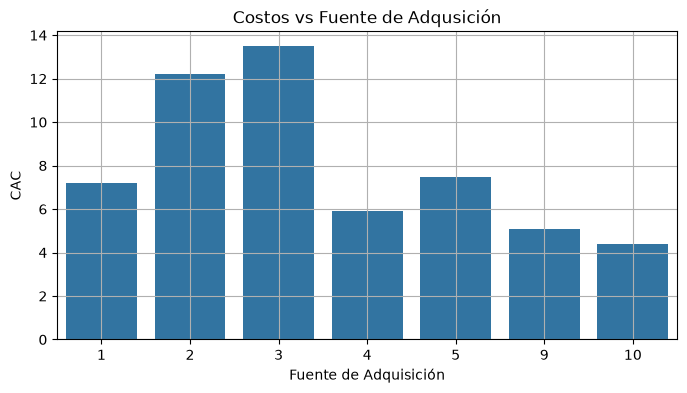

In [101]:
# Visualización de CAC por Fuente de Adquisición
plt.figure(figsize=(8,4))
sns.barplot(
    x='source_id',
    y='cac',
    data=costs_resume_reset
)
plt.title('Costos vs Fuente de Adqusición')
plt.xlabel('Fuente de Adquisición')
plt.ylabel('CAC')
plt.grid(True)
plt.show()

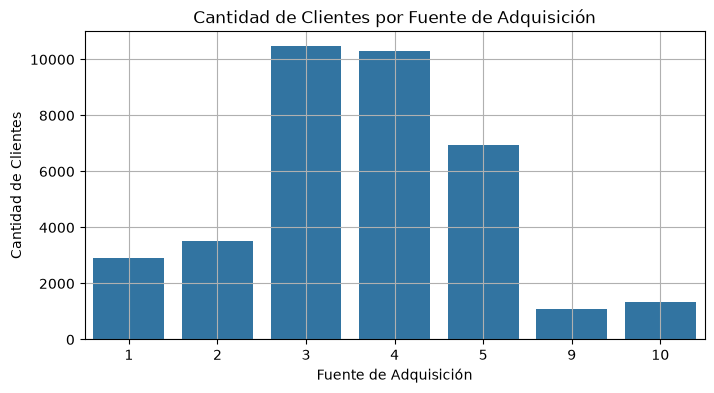

In [102]:
plt.figure(figsize=(8,4))
sns.barplot(
    x='source_id',
    y='customers',
    data=costs_resume_reset
)
plt.title('Cantidad de Clientes por Fuente de Adquisición')
plt.xlabel('Fuente de Adquisición')
plt.ylabel('Cantidad de Clientes')
plt.grid(True)
plt.show()

#### Análisis del CAC
Para resumir los comentarios por fuente:
* La fuente 10 es la más eficiente en términos de adquisición, ya que requiere la menor inversión para captar cada cliente. Aunque su volumen total de usuarios es reducido, representa una oportunidad interesante para incrementar presupuesto y evaluar su escalabilidad.
* La fuente 9 también muestra una alta eficiencia de adquisición. Con un CAC bajo y resultados relativamente consistentes, podría considerarse una fuente rentable para futuras campañas.
* La fuente 4 destaca por combinar un CAC bajo con un volumen elevado de clientes captados, convirtiéndose en una de las fuentes más atractivas desde el punto de vista de eficiencia y escala.
* La fuente 3 genera la mayor cantidad de clientes, pero también presenta el CAC más alto. Esto indica que el crecimiento obtenido depende de una inversión considerable, por lo que será necesario validar posteriormente si los ingresos generados compensan dicho costo mediante métricas como ROMI o LTV.
* La fuente 2 muestra un CAC elevado y un volumen de clientes significativamente menor que la fuente 3, lo que podría indicar una menor eficiencia relativa en la adquisición.

Sobre el gráfico de clientes:
* Las fuentes 3 y 4 son responsables de la mayor parte de los clientes adquiridos.
* La fuente 5 ocupa una posición intermedia.
* Las fuentes 9 y 10 captan pocos usuarios, aunque a costos bajos.

Por lo tanto, el análisis de CAC evidencia diferencias significativas entre las fuentes de adquisición. Las fuentes 3 y 4 concentran la mayor captación de clientes, aunque la fuente 3 presenta el costo de adquisición más elevado (13.49), mientras que la fuente 4 logra un equilibrio favorable entre volumen y eficiencia (CAC de 5.93). Por otro lado, las fuentes 9 y 10 muestran los menores costos de adquisición, pero aportan una cantidad limitada de clientes. Estos resultados sugieren que la evaluación final del desempeño de cada fuente debe complementarse con métricas de rentabilidad, como LTV y ROMI, para determinar cuáles generan mayor valor económico para la empresa.

## Análisis de Rentabilidad de las Inversiones en Marketing (ROMI)
Una vez analizados los ingresos generados por los usuarios, el costo de adquisición de clientes (CAC) y el valor aportado por las distintas cohortes de clientes (LTV), resulta fundamental evaluar si las inversiones realizadas en marketing fueron rentables para la empresa.

Para ello, se calculará el ROMI (Return on Marketing Investment), una métrica que mide la rentabilidad obtenida por cada unidad monetaria invertida en actividades de adquisición. Este indicador permite identificar qué fuentes de marketing generan valor económico para el negocio y cuáles podrían estar consumiendo presupuesto sin generar retornos suficientes.

El análisis se realizará tanto a nivel global como por fuente de adquisición y evolución temporal, permitiendo detectar diferencias en el desempeño de los canales de marketing y apoyar futuras decisiones de asignación presupuestaria.

In [103]:
# Obtener la primera vista por usuario --> evitar duplicados (solo usuarios que han pedido)
first_visits_romi = (visits.sort_values('start_ts').drop_duplicates(subset='uid', keep='first'))
first_visits_romi = first_visits_romi[['uid', 'source_id']]

# Unir pedidos por Fuente de Adqusición
order_source_first_visit = orders.merge(first_visits_romi, on='uid', how='left')

# Calcular revenue por fuente
revenue_source = order_source_first_visit.groupby('source_id')['revenue'].sum()

# Unir revenue y costs
romi_source = pd.merge(revenue_source, costs_source, left_index=True, right_index=True)
romi_source.columns = ['revenue', 'costs']

In [104]:
# Calculo de ROMI por Fuente
romi_source['romi'] = (romi_source['revenue'] - romi_source['costs']) / romi_source['costs']

print('Tabla de ingresos y costos para calcular el ROMI:')
print(romi_source.round(2))

Tabla de ingresos y costos para calcular el ROMI:
            revenue      costs  romi
source_id                           
1          31090.55   20833.27  0.49
2          46923.61   42806.04  0.10
3          54511.24  141321.63 -0.61
4          56696.83   61073.60 -0.07
5          52624.02   51757.10  0.02
9           5759.40    5517.49  0.04
10          4450.33    5822.49 -0.24


In [106]:
# ROMI a lo largo del tiempo mensual
order_source_first_visit['month'] = order_source_first_visit['buy_ts'].dt.to_period('M')

revenue_monthly = order_source_first_visit.groupby('month')['revenue'].sum()
costs_monthly = costs.groupby('month')['costs'].sum()

romi_monthly = (revenue_monthly - costs_monthly) / costs_monthly

print('ROMI mensual:')
print(romi_monthly)

ROMI mensual:
month
2017-06   -0.469470
2017-07   -0.312551
2017-08   -0.407812
2017-09   -0.247176
2017-10   -0.229475
2017-11   -0.285902
2017-12   -0.050287
2018-01   -0.420704
2018-02   -0.218882
2018-03   -0.051970
2018-04   -0.243673
2018-05   -0.066967
2018-06         NaN
Freq: M, dtype: float64


In [105]:
# ROMI total del negocio
total_revenue = orders['revenue'].sum()

romi_total = (total_revenue - total_costs) / total_costs
print(f'ROMI total: {romi_total:.2f}')

ROMI total: -0.23


#### Análisis ROMI
El análisis de rentabilidad de las inversiones en marketing muestra que, aunque algunas fuentes de adquisición lograron generar retornos positivos, el desempeño global de la estrategia de marketing fue negativo durante el período analizado.

El ROMI total del negocio alcanzó -0.23, lo que significa que por cada unidad monetaria invertida en marketing la empresa perdió aproximadamente un 23% de su inversión. Esto indica que los ingresos generados por los clientes adquiridos no fueron suficientes para compensar completamente los costos de adquisición.

El análisis mensual revela que:
* Ningún mes alcanzó rentabilidad positiva.
* Todos los períodos presentan ROMI negativo.
* Existe una mejora progresiva durante algunos meses (especialmente hacia diciembre y marzo).
* Sin embargo, el negocio no logró superar el punto de equilibrio en ningún momento.

Recomendaciones:
* Reducir la inversión de la Fuente 3.
* Incrementar la inversión de la Fuente 1.
* Optimizar Fuentes 2, 5 y 9.
* Revisar la estrategia global de adquisición.

## Conclusión del Proyecto
El análisis integral del comportamiento de los usuarios, las conversiones, el valor generado por cliente (LTV), los costos de adquisición (CAC) y la rentabilidad de las inversiones en marketing (ROMI) permitió identificar oportunidades relevantes para optimizar el crecimiento y la rentabilidad de la plataforma.

Los resultados muestran que la mayor parte del valor generado por los usuarios se concentra durante los primeros días posteriores a su adquisición. La mayoría de las compras ocurren el mismo día de la primera visita o dentro de la primera semana, mientras que la probabilidad de conversión disminuye considerablemente con el paso del tiempo. Esto indica que las estrategias de captación y activación temprana tienen un impacto crítico sobre los resultados del negocio.

Asimismo, el análisis de cohortes revela que los usuarios continúan generando ingresos durante varios meses, aunque el aporte marginal disminuye progresivamente. La cohorte de junio de 2017 presentó el mejor desempeño, alcanzando un LTV acumulado cercano a 3 unidades monetarias por usuario, demostrando que ciertos grupos de clientes poseen un valor significativamente superior al promedio.

Desde la perspectiva de marketing, se observó una fuerte concentración del presupuesto en la fuente de adquisición 3, la cual absorbió aproximadamente el 43% de la inversión total. Sin embargo, esta fuente presentó el peor desempeño financiero, registrando el CAC más elevado y un ROMI de -61%, lo que indica una utilización ineficiente de los recursos publicitarios.

Por el contrario, la fuente 1 demostró ser el canal más rentable, alcanzando un ROMI de 49%, mientras que las fuentes 2, 5 y 9 también lograron resultados positivos, aunque más moderados. Estos hallazgos sugieren que existe una oportunidad importante para redistribuir el presupuesto hacia los canales más eficientes y reducir la inversión en aquellos que generan pérdidas.

Finalmente, aunque la plataforma mantiene una base sólida de usuarios activos y un flujo constante de pedidos, el análisis financiero evidencia que la estrategia global de adquisición aún no es rentable, reflejándose en un ROMI total de -23%. Para mejorar el desempeño del negocio, se recomienda optimizar la asignación de presupuesto entre canales, fortalecer las acciones de conversión durante los primeros días de vida del usuario y desarrollar estrategias de retención que incrementen el valor generado a largo plazo.

En conclusión, el principal desafío de la empresa no es atraer más usuarios, sino adquirir usuarios de mayor valor y maximizar su conversión y retención mediante una inversión de marketing más eficiente y orientada a la rentabilidad. Es decir, los resultados indican que el crecimiento futuro de la empresa dependerá menos del volumen de usuarios adquiridos y más de la capacidad de atraer clientes rentables, optimizar la conversión temprana y asignar estratégicamente la inversión hacia los canales con mayor retorno económico.